In [1]:
# Cell 1 — Load dataset_v2.csv and confirm shape
from pathlib import Path
import pandas as pd
import numpy as np

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATASET_PATH = REPO_ROOT / "data" / "processed" / "dataset_v2.csv"

dataset = pd.read_csv(DATASET_PATH, parse_dates=["date_parsed"])

print(f"Shape: {dataset.shape}")
print(f"Columns: {len(dataset.columns)}")
print(f"Date range: {dataset['date_parsed'].min().date()} → {dataset['date_parsed'].max().date()}")
print(f"Tickers: {dataset['ticker'].nunique()}")
print(f"\nColumn list:")
for col in dataset.columns:
    print(f"  {col}")

Shape: (273, 52)
Columns: 52
Date range: 2019-06-25 → 2023-02-02
Tickers: 30

Column list:
  ticker
  quarter
  date_parsed
  word_count
  sentence_count
  avg_sentence_length
  flesch_kincaid_grade
  numeric_density
  negative_count
  uncertainty_count
  litigious_count
  forward_looking_count
  word_count_zscore
  sentence_count_zscore
  avg_sentence_length_zscore
  flesch_kincaid_grade_zscore
  numeric_density_zscore
  negative_count_zscore
  uncertainty_count_zscore
  litigious_count_zscore
  forward_looking_count_zscore
  excess_return_1d
  excess_return_3d
  excess_return_5d
  y_1d
  y_3d
  y_5d
  prep_pos_mean
  prep_neu_mean
  prep_neg_mean
  prep_pos_share
  prep_neg_share
  prep_n_chunks
  qa_pos_mean
  qa_neu_mean
  qa_neg_mean
  qa_pos_share
  qa_neg_share
  qa_n_chunks
  call_seconds
  prep_pos_mean_zscore
  prep_neu_mean_zscore
  prep_neg_mean_zscore
  prep_pos_share_zscore
  prep_neg_share_zscore
  prep_n_chunks_zscore
  qa_pos_mean_zscore
  qa_neu_mean_zscore
  qa_neg_m

In [2]:
# Cell 2 — Feature list definitions

# Day 3 reproduction (for Block 2 sanity check)
RAW_LEXICON = [
    "word_count", "sentence_count", "avg_sentence_length",
    "flesch_kincaid_grade", "numeric_density",
    "negative_count", "uncertainty_count", "litigious_count",
    "forward_looking_count",
]
ZSCORE_LEXICON = [f"{c}_zscore" for c in RAW_LEXICON]
FEATURES_DAY3_18 = RAW_LEXICON + ZSCORE_LEXICON  # 18 features, Day 3 baseline

# Day 5 feature families (z-scored only)
FEATURES_LEXICON = ZSCORE_LEXICON  # 9 features

FEATURES_FINBERT = [
    "prep_pos_mean_zscore", "prep_neu_mean_zscore", "prep_neg_mean_zscore",
    "qa_pos_mean_zscore", "qa_neu_mean_zscore", "qa_neg_mean_zscore",
    "prep_n_chunks_zscore", "qa_n_chunks_zscore",
]  # 8 features — *_share_zscore dropped (0.80 corr with *_mean_zscore)

FEATURES_COMBINED = FEATURES_LEXICON + FEATURES_FINBERT  # 17 features

TARGET_COLS = ["y_1d", "y_3d", "y_5d"]

# Verify every feature exists in dataset
all_features = set(FEATURES_DAY3_18 + FEATURES_COMBINED)
missing = all_features - set(dataset.columns)
assert not missing, f"Missing columns: {missing}"

print(f"FEATURES_DAY3_18:  {len(FEATURES_DAY3_18)} features (Block 2 sanity check)")
print(f"FEATURES_LEXICON:  {len(FEATURES_LEXICON)} features (z-scored lexicon)")
print(f"FEATURES_FINBERT:  {len(FEATURES_FINBERT)} features (z-scored FinBERT)")
print(f"FEATURES_COMBINED: {len(FEATURES_COMBINED)} features (Block 3 main model)")
print(f"\nAll {len(all_features)} unique features present in dataset ✓")

FEATURES_DAY3_18:  18 features (Block 2 sanity check)
FEATURES_LEXICON:  9 features (z-scored lexicon)
FEATURES_FINBERT:  8 features (z-scored FinBERT)
FEATURES_COMBINED: 17 features (Block 3 main model)

All 26 unique features present in dataset ✓


In [3]:
# Cell 3 — Time-based split (exact Day 3 reproduction)
TRAIN_END = pd.Timestamp("2022-08-01")
VAL_END = pd.Timestamp("2022-10-01")

train_df = dataset[dataset["date_parsed"] < TRAIN_END].copy()
val_df = dataset[(dataset["date_parsed"] >= TRAIN_END) & (dataset["date_parsed"] < VAL_END)].copy()
test_df = dataset[dataset["date_parsed"] >= VAL_END].copy()

# Sort each split by date (needed for TimeSeriesSplit later)
train_df = train_df.sort_values("date_parsed").reset_index(drop=True)
val_df = val_df.sort_values("date_parsed").reset_index(drop=True)
test_df = test_df.sort_values("date_parsed").reset_index(drop=True)

# Day 3 confirmed: 218 / 11 / 44
assert len(train_df) == 218, f"Train size mismatch: got {len(train_df)}, expected 218"
assert len(val_df) == 11, f"Val size mismatch: got {len(val_df)}, expected 11"
assert len(test_df) == 44, f"Test size mismatch: got {len(test_df)}, expected 44"
assert len(train_df) + len(val_df) + len(test_df) == 273

# Temporal ordering
assert train_df["date_parsed"].max() < val_df["date_parsed"].min(), "Train/val overlap!"
assert val_df["date_parsed"].max() < test_df["date_parsed"].min(), "Val/test overlap!"

print("Split (matches Day 3 exactly):")
print(f"  Train: {len(train_df):3d} rows  ({train_df['date_parsed'].min().date()} → {train_df['date_parsed'].max().date()})")
print(f"  Val:   {len(val_df):3d} rows  ({val_df['date_parsed'].min().date()} → {val_df['date_parsed'].max().date()})")
print(f"  Test:  {len(test_df):3d} rows  ({test_df['date_parsed'].min().date()} → {test_df['date_parsed'].max().date()})")

# Class balance per window
print("\nClass balance (positive rate %):")
print(f"  {'Window':<6} {'Train':>8} {'Val':>8} {'Test':>8}")
for w in TARGET_COLS:
    tr = train_df[w].mean() * 100
    va = val_df[w].mean() * 100
    te = test_df[w].mean() * 100
    print(f"  {w:<6} {tr:>7.1f}% {va:>7.1f}% {te:>7.1f}%")

# NaN audit on FinBERT features (interview / qa_missing rows)
print("\nNaN counts in FinBERT features (expected: ~21 NFLX+TSLA interview + 1 PYPL qa_missing):")
nan_counts = dataset[FEATURES_FINBERT].isna().sum()
print(nan_counts[nan_counts > 0])

Split (matches Day 3 exactly):
  Train: 218 rows  (2019-06-25 → 2022-07-29)
  Val:    11 rows  (2022-08-02 → 2022-09-22)
  Test:   44 rows  (2022-10-14 → 2023-02-02)

Class balance (positive rate %):
  Window    Train      Val     Test
  y_1d      50.0%    36.4%    52.3%
  y_3d      50.9%    45.5%    45.5%
  y_5d      50.0%    36.4%    52.3%

NaN counts in FinBERT features (expected: ~21 NFLX+TSLA interview + 1 PYPL qa_missing):
prep_pos_mean_zscore    21
prep_neu_mean_zscore    21
prep_neg_mean_zscore    21
qa_pos_mean_zscore       1
qa_neu_mean_zscore       1
qa_neg_mean_zscore       1
prep_n_chunks_zscore    21
dtype: int64


In [ ]:
# Cell 4 — Load Day 3's saved models and run them on the same test set
import joblib
from sklearn.metrics import roc_auc_score

MODELS_DIR = REPO_ROOT / "models"

# Check what's on disk
print("Files in models/ directory:")
if MODELS_DIR.exists():
    for f in sorted(MODELS_DIR.iterdir()):
        size_kb = f.stat().st_size / 1024
        print(f"  {f.name:<35} {size_kb:>8.1f} KB")
else:
    print("  models/ directory does not exist")


Files in models/ directory:
  feature_cols.joblib                      0.4 KB
  model_y1d_lr_v1.joblib                   2.5 KB
  model_y3d_lr_v2.joblib                   2.5 KB
  model_y5d_xgboost.joblib               101.3 KB


In [5]:
# Cell 5 — Load Day 3 models and reproduce test AUCs
import joblib
from sklearn.metrics import roc_auc_score

# Load all three models + the feature list Day 3 used
model_y1d = joblib.load(MODELS_DIR / "model_y1d_lr_v1.joblib")
model_y3d = joblib.load(MODELS_DIR / "model_y3d_lr_v2.joblib")
model_y5d = joblib.load(MODELS_DIR / "model_y5d_xgboost.joblib")
day3_feature_cols = joblib.load(MODELS_DIR / "feature_cols.joblib")

# Sanity: confirm Day 3 used the 18-feature set we expect
print(f"Day 3 used {len(day3_feature_cols)} features:")
for f in day3_feature_cols:
    print(f"  {f}")
assert set(day3_feature_cols) == set(FEATURES_DAY3_18), \
    "Day 3 feature list differs from FEATURES_DAY3_18!"
print("\n✓ Day 3 feature list matches FEATURES_DAY3_18\n")

# Build X_test using Day 3's exact feature order
X_test = test_df[day3_feature_cols].copy()
y_test = {w: test_df[w].copy() for w in TARGET_COLS}

# Predict on test for each window
day3_test_aucs = {}
for window, model in [("y_1d", model_y1d), ("y_3d", model_y3d), ("y_5d", model_y5d)]:
    test_pred_proba = model.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test[window], test_pred_proba)
    day3_test_aucs[window] = test_auc

# Compare to Day 3 resume's reported numbers
DAY3_REPORTED = {"y_1d": 0.375, "y_3d": 0.525, "y_5d": 0.538}

print(f"{'Window':<6} {'Day 3 reported':>15} {'Reproduced':>12} {'Δ':>8}")
print("-" * 45)
for w in TARGET_COLS:
    reported = DAY3_REPORTED[w]
    got = day3_test_aucs[w]
    delta = got - reported
    print(f"{w:<6} {reported:>15.3f} {got:>12.3f} {delta:>+8.3f}")

Day 3 used 18 features:
  word_count
  sentence_count
  avg_sentence_length
  flesch_kincaid_grade
  numeric_density
  negative_count
  uncertainty_count
  litigious_count
  forward_looking_count
  word_count_zscore
  sentence_count_zscore
  avg_sentence_length_zscore
  flesch_kincaid_grade_zscore
  numeric_density_zscore
  negative_count_zscore
  uncertainty_count_zscore
  litigious_count_zscore
  forward_looking_count_zscore

✓ Day 3 feature list matches FEATURES_DAY3_18

Window  Day 3 reported   Reproduced        Δ
---------------------------------------------
y_1d             0.375        0.375   -0.000
y_3d             0.525        0.525   +0.000
y_5d             0.538        0.538   +0.000


In [6]:
# Cell 6 — Prepare X/y for LR (drop NaN rows) and XGBoost (keep all rows)

# Full training set (XGBoost handles NaN natively)
X_train_full = train_df[FEATURES_COMBINED].copy()
y_train_full = {w: train_df[w].copy() for w in TARGET_COLS}

# Clean training set (LR cannot handle NaN — drop rows with any NaN in FinBERT features)
nan_mask_train = train_df[FEATURES_FINBERT].isna().any(axis=1)
train_clean_df = train_df[~nan_mask_train].copy().reset_index(drop=True)
X_train_clean = train_clean_df[FEATURES_COMBINED].copy()
y_train_clean = {w: train_clean_df[w].copy() for w in TARGET_COLS}

# Val and test — check NaN counts (should be tiny)
nan_mask_val = val_df[FEATURES_FINBERT].isna().any(axis=1)
nan_mask_test = test_df[FEATURES_FINBERT].isna().any(axis=1)

# For val/test, also produce clean versions (for LR evaluation)
val_clean_df = val_df[~nan_mask_val].copy().reset_index(drop=True)
test_clean_df = test_df[~nan_mask_test].copy().reset_index(drop=True)

X_val_full = val_df[FEATURES_COMBINED].copy()
X_val_clean = val_clean_df[FEATURES_COMBINED].copy()
y_val_full = {w: val_df[w].copy() for w in TARGET_COLS}
y_val_clean = {w: val_clean_df[w].copy() for w in TARGET_COLS}

X_test_combined_full = test_df[FEATURES_COMBINED].copy()
X_test_combined_clean = test_clean_df[FEATURES_COMBINED].copy()
y_test_clean = {w: test_clean_df[w].copy() for w in TARGET_COLS}

# Report
print("Training sets prepared:")
print(f"  X_train_full  (for XGBoost): {X_train_full.shape}  NaN rows kept: {nan_mask_train.sum()}")
print(f"  X_train_clean (for LR):      {X_train_clean.shape}  NaN rows dropped")
print()
print("Validation sets:")
print(f"  X_val_full  (for XGBoost): {X_val_full.shape}  NaN rows: {nan_mask_val.sum()}")
print(f"  X_val_clean (for LR):      {X_val_clean.shape}")
print()
print("Test sets:")
print(f"  X_test_combined_full  (for XGBoost): {X_test_combined_full.shape}  NaN rows: {nan_mask_test.sum()}")
print(f"  X_test_combined_clean (for LR):      {X_test_combined_clean.shape}")

# Sanity: confirm no NaN in clean sets
assert X_train_clean.isna().sum().sum() == 0, "Clean train still has NaN!"
assert X_val_clean.isna().sum().sum() == 0, "Clean val still has NaN!"
assert X_test_combined_clean.isna().sum().sum() == 0, "Clean test still has NaN!"
print("\n✓ All clean sets confirmed NaN-free")

# Report class balance on clean train (in case dropping interview rows shifted it)
print("\nClass balance on clean train (should still be ~50% for y_3d, y_5d):")
for w in TARGET_COLS:
    full_rate = y_train_full[w].mean() * 100
    clean_rate = y_train_clean[w].mean() * 100
    print(f"  {w}: full {full_rate:.1f}% → clean {clean_rate:.1f}%  (Δ {clean_rate-full_rate:+.1f}%)")

Training sets prepared:
  X_train_full  (for XGBoost): (218, 17)  NaN rows kept: 18
  X_train_clean (for LR):      (200, 17)  NaN rows dropped

Validation sets:
  X_val_full  (for XGBoost): (11, 17)  NaN rows: 0
  X_val_clean (for LR):      (11, 17)

Test sets:
  X_test_combined_full  (for XGBoost): (44, 17)  NaN rows: 4
  X_test_combined_clean (for LR):      (40, 17)

✓ All clean sets confirmed NaN-free

Class balance on clean train (should still be ~50% for y_3d, y_5d):
  y_1d: full 50.0% → clean 49.0%  (Δ -1.0%)
  y_3d: full 50.9% → clean 51.0%  (Δ +0.1%)
  y_5d: full 50.0% → clean 50.5%  (Δ +0.5%)


In [7]:
# Cell 7 — TimeSeriesSplit setup (reuse Day 3's CV configuration)
from sklearn.model_selection import TimeSeriesSplit

N_SPLITS = 5

# Two CV splitters — one for each training set
# Same params, different data they'll be applied to
tscv_full = TimeSeriesSplit(n_splits=N_SPLITS)   # for XGBoost on X_train_full (218 rows)
tscv_clean = TimeSeriesSplit(n_splits=N_SPLITS)  # for LR on X_train_clean (200 rows)

# Confirm fold sizes for both
print("TimeSeriesSplit fold sizes:\n")

print(f"Full train (218 rows) → XGBoost folds:")
for i, (train_idx, val_idx) in enumerate(tscv_full.split(X_train_full), 1):
    print(f"  Fold {i}: train={len(train_idx):3d}  val={len(val_idx):2d}")

print(f"\nClean train (200 rows) → LR folds:")
for i, (train_idx, val_idx) in enumerate(tscv_clean.split(X_train_clean), 1):
    print(f"  Fold {i}: train={len(train_idx):3d}  val={len(val_idx):2d}")

# Date range sanity: confirm folds progress forward in time
print(f"\nFold 5 (final) date ranges on full train:")
final_train_idx, final_val_idx = list(tscv_full.split(X_train_full))[-1]
final_train_dates = train_df.iloc[final_train_idx]["date_parsed"]
final_val_dates = train_df.iloc[final_val_idx]["date_parsed"]
print(f"  Train portion: {final_train_dates.min().date()} → {final_train_dates.max().date()}  ({len(final_train_idx)} rows)")
print(f"  Val portion:   {final_val_dates.min().date()} → {final_val_dates.max().date()}  ({len(final_val_idx)} rows)")

TimeSeriesSplit fold sizes:

Full train (218 rows) → XGBoost folds:
  Fold 1: train= 38  val=36
  Fold 2: train= 74  val=36
  Fold 3: train=110  val=36
  Fold 4: train=146  val=36
  Fold 5: train=182  val=36

Clean train (200 rows) → LR folds:
  Fold 1: train= 35  val=33
  Fold 2: train= 68  val=33
  Fold 3: train=101  val=33
  Fold 4: train=134  val=33
  Fold 5: train=167  val=33

Fold 5 (final) date ranges on full train:
  Train portion: 2019-06-25 → 2022-04-26  (182 rows)
  Val portion:   2022-04-27 → 2022-07-29  (36 rows)


In [8]:
# Cell 8 — Tune LR on combined features (lexicon-z + FinBERT-z, 17 features)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings("ignore", category=UserWarning)  # L1+saga convergence noise

# Day 3 LR v2 grid (extended regularization — found 3-feature winner for y_3d)
LR_PARAM_GRID = {
    "logreg__C": [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0],
    "logreg__penalty": ["l1", "l2"],
    "logreg__class_weight": [None, "balanced"],
}

def build_lr_pipeline():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(solver="saga", max_iter=5000, random_state=42)),
    ])

# Only tune y_3d and y_5d (skipping y_1d — Day 3 proved it's regime-dominated)
WINDOWS_TO_TUNE = ["y_3d", "y_5d"]

lr_combined_results = {}
for window in WINDOWS_TO_TUNE:
    print(f"Tuning LR on combined features for {window}...")
    pipeline = build_lr_pipeline()
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=LR_PARAM_GRID,
        n_iter=32,
        scoring="roc_auc",
        cv=tscv_clean,
        random_state=42,
        n_jobs=-1,
        return_train_score=True,
    )
    search.fit(X_train_clean, y_train_clean[window])

    best_pipeline = search.best_estimator_
    final_lr = best_pipeline.named_steps["logreg"]
    n_nonzero = int((final_lr.coef_ != 0).sum())

    # Evaluate on holdout val (clean, n=11)
    val_pred_proba = best_pipeline.predict_proba(X_val_clean)[:, 1]
    val_auc = roc_auc_score(y_val_clean[window], val_pred_proba)

    lr_combined_results[window] = {
        "best_params": search.best_params_,
        "mean_cv_val_auc": search.best_score_,
        "mean_cv_train_auc": search.cv_results_["mean_train_score"][search.best_index_],
        "cv_std": search.cv_results_["std_test_score"][search.best_index_],
        "val_auc_holdout": val_auc,
        "model": best_pipeline,
        "n_nonzero_features": n_nonzero,
    }

# Report
print("\n" + "="*70)
print("LR tuning results on combined features (17 total, lex-z + FinBERT-z)")
print("="*70)
for w in WINDOWS_TO_TUNE:
    r = lr_combined_results[w]
    print(f"\n{w}:")
    print(f"  Best params:        {r['best_params']}")
    print(f"  CV val AUC (mean):  {r['mean_cv_val_auc']:.3f}  (std {r['cv_std']:.3f})")
    print(f"  CV train AUC:       {r['mean_cv_train_auc']:.3f}  (gap {r['mean_cv_train_auc']-r['mean_cv_val_auc']:+.3f})")
    print(f"  Holdout val AUC:    {r['val_auc_holdout']:.3f}  (n=11, noisy)")
    print(f"  Features kept:      {r['n_nonzero_features']}/17")

# Compare to Day 3's LR v2 numbers for these windows
print("\n" + "="*70)
print("Comparison to Day 3 (LR v2 on lexicon-only 18 features)")
print("="*70)
DAY3_LR_V2 = {
    "y_3d": {"cv_val": 0.542, "features": 3},
    "y_5d": {"cv_val": 0.530, "features": 15},
}
print(f"{'Window':<6} {'Day 3 CV AUC':>14} {'Day 5 CV AUC':>14} {'Δ':>8} {'D3 feats':>9} {'D5 feats':>9}")
for w in WINDOWS_TO_TUNE:
    d3 = DAY3_LR_V2[w]
    d5 = lr_combined_results[w]
    delta = d5['mean_cv_val_auc'] - d3['cv_val']
    print(f"{w:<6} {d3['cv_val']:>14.3f} {d5['mean_cv_val_auc']:>14.3f} {delta:>+8.3f} {d3['features']:>9d} {d5['n_nonzero_features']:>9d}")

Tuning LR on combined features for y_3d...
Tuning LR on combined features for y_5d...

LR tuning results on combined features (17 total, lex-z + FinBERT-z)

y_3d:
  Best params:        {'logreg__penalty': 'l2', 'logreg__class_weight': 'balanced', 'logreg__C': 0.05}
  CV val AUC (mean):  0.572  (std 0.054)
  CV train AUC:       0.810  (gap +0.239)
  Holdout val AUC:    0.600  (n=11, noisy)
  Features kept:      17/17

y_5d:
  Best params:        {'logreg__penalty': 'l2', 'logreg__class_weight': None, 'logreg__C': 0.05}
  CV val AUC (mean):  0.578  (std 0.066)
  CV train AUC:       0.787  (gap +0.209)
  Holdout val AUC:    0.500  (n=11, noisy)
  Features kept:      17/17

Comparison to Day 3 (LR v2 on lexicon-only 18 features)
Window   Day 3 CV AUC   Day 5 CV AUC        Δ  D3 feats  D5 feats
y_3d            0.542          0.572   +0.030         3        17
y_5d            0.530          0.578   +0.048        15        17


In [9]:
# Cell 9 — Tune XGBoost on combined features (Day 3 grid, applied to 17-feature set)
from xgboost import XGBClassifier
import time

XGB_PARAM_GRID = {
    "n_estimators": [30, 50, 100],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.05, 0.1],
    "min_child_weight": [1, 5, 10],
    "reg_alpha": [0, 0.1, 1.0],
    "reg_lambda": [1, 2, 5],
}
XGB_FIXED_PARAMS = {
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "eval_metric": "auc",
    "n_jobs": 1,
}

xgb_combined_results = {}
for window in WINDOWS_TO_TUNE:
    print(f"Tuning XGBoost on combined features for {window}...")
    t0 = time.time()
    base_model = XGBClassifier(**XGB_FIXED_PARAMS)
    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=XGB_PARAM_GRID,
        n_iter=50,
        scoring="roc_auc",
        cv=tscv_full,
        random_state=42,
        n_jobs=-1,
        return_train_score=True,
    )
    search.fit(X_train_full, y_train_full[window])

    best_model = search.best_estimator_
    val_pred_proba = best_model.predict_proba(X_val_full)[:, 1]
    val_auc = roc_auc_score(y_val_full[window], val_pred_proba)

    xgb_combined_results[window] = {
        "best_params": search.best_params_,
        "mean_cv_val_auc": search.best_score_,
        "mean_cv_train_auc": search.cv_results_["mean_train_score"][search.best_index_],
        "cv_std": search.cv_results_["std_test_score"][search.best_index_],
        "val_auc_holdout": val_auc,
        "model": best_model,
    }
    print(f"  ...done in {time.time()-t0:.1f}s")

# Report
print("\n" + "="*70)
print("XGBoost tuning results on combined features (17 total)")
print("="*70)
for w in WINDOWS_TO_TUNE:
    r = xgb_combined_results[w]
    print(f"\n{w}:")
    print(f"  Best params:")
    for k, v in r['best_params'].items():
        print(f"    {k}: {v}")
    print(f"  CV val AUC (mean):  {r['mean_cv_val_auc']:.3f}  (std {r['cv_std']:.3f})")
    print(f"  CV train AUC:       {r['mean_cv_train_auc']:.3f}  (gap {r['mean_cv_train_auc']-r['mean_cv_val_auc']:+.3f})")
    print(f"  Holdout val AUC:    {r['val_auc_holdout']:.3f}  (n=11, noisy)")

# Compare to Day 3 XGBoost (same model type, lexicon-only 18 features)
print("\n" + "="*70)
print("Comparison to Day 3 XGBoost (lexicon-only)")
print("="*70)
DAY3_XGB = {
    "y_3d": {"cv_val": 0.576},
    "y_5d": {"cv_val": 0.547},
}
print(f"{'Window':<6} {'Day 3 CV AUC':>14} {'Day 5 CV AUC':>14} {'Δ':>8}")
for w in WINDOWS_TO_TUNE:
    d3 = DAY3_XGB[w]
    d5 = xgb_combined_results[w]
    delta = d5['mean_cv_val_auc'] - d3['cv_val']
    print(f"{w:<6} {d3['cv_val']:>14.3f} {d5['mean_cv_val_auc']:>14.3f} {delta:>+8.3f}")

# Full 4-way comparison table: LR/XGB × Day3/Day5
print("\n" + "="*70)
print("Full comparison: model × feature set (CV val AUC)")
print("="*70)
print(f"{'Window':<6} | {'LR (D3 lex)':>11} | {'LR (D5 combo)':>13} | {'XGB (D3 lex)':>12} | {'XGB (D5 combo)':>14}")
print("-" * 75)
DAY3_LR = {"y_3d": 0.542, "y_5d": 0.530}
for w in WINDOWS_TO_TUNE:
    print(f"{w:<6} | {DAY3_LR[w]:>11.3f} | {lr_combined_results[w]['mean_cv_val_auc']:>13.3f} | {DAY3_XGB[w]['cv_val']:>12.3f} | {xgb_combined_results[w]['mean_cv_val_auc']:>14.3f}")

Tuning XGBoost on combined features for y_3d...
  ...done in 4.4s
Tuning XGBoost on combined features for y_5d...
  ...done in 1.5s

XGBoost tuning results on combined features (17 total)

y_3d:
  Best params:
    reg_lambda: 5
    reg_alpha: 0.1
    n_estimators: 100
    min_child_weight: 1
    max_depth: 2
    learning_rate: 0.05
  CV val AUC (mean):  0.596  (std 0.038)
  CV train AUC:       0.974  (gap +0.378)
  Holdout val AUC:    0.700  (n=11, noisy)

y_5d:
  Best params:
    reg_lambda: 1
    reg_alpha: 1.0
    n_estimators: 50
    min_child_weight: 5
    max_depth: 4
    learning_rate: 0.01
  CV val AUC (mean):  0.573  (std 0.062)
  CV train AUC:       0.758  (gap +0.184)
  Holdout val AUC:    0.536  (n=11, noisy)

Comparison to Day 3 XGBoost (lexicon-only)
Window   Day 3 CV AUC   Day 5 CV AUC        Δ
y_3d            0.576          0.596   +0.020
y_5d            0.547          0.573   +0.026

Full comparison: model × feature set (CV val AUC)
Window | LR (D3 lex) | LR (D5 combo)

In [10]:
# Cell 10 — One-shot test evaluation of pre-committed Day 5 models
from sklearn.metrics import roc_auc_score

# Pre-committed choices (locked before this cell runs):
# y_3d → XGBoost on combined features (X_train_full, 17 feat)
# y_5d → LR on combined features (X_train_clean, 17 feat)

shipping_models = {
    "y_3d": {
        "model_obj": xgb_combined_results["y_3d"]["model"],
        "model_type": "xgboost",
        "X_test": X_test_combined_full,    # 44 rows, NaN kept
        "y_test": y_test["y_3d"],          # 44 rows (using full y_test from Cell 5)
        "cv_val_auc": xgb_combined_results["y_3d"]["mean_cv_val_auc"],
    },
    "y_5d": {
        "model_obj": lr_combined_results["y_5d"]["model"],
        "model_type": "lr",
        "X_test": X_test_combined_clean,   # 40 rows, NaN dropped
        "y_test": y_test_clean["y_5d"],    # 40 rows
        "cv_val_auc": lr_combined_results["y_5d"]["mean_cv_val_auc"],
    },
}

# Run predictions
test_results_day5 = {}
for window, info in shipping_models.items():
    pred_proba = info["model_obj"].predict_proba(info["X_test"])[:, 1]
    test_auc = roc_auc_score(info["y_test"], pred_proba)
    test_results_day5[window] = {
        "model_type": info["model_type"],
        "test_auc": test_auc,
        "cv_val_auc": info["cv_val_auc"],
        "test_n": len(info["y_test"]),
        "pred_proba": pred_proba,
    }

# Footnote: also run XGBoost y_3d on clean (40-row) test, to isolate the NaN-row effect
xgb_y3d_on_clean_pred = xgb_combined_results["y_3d"]["model"].predict_proba(X_test_combined_clean)[:, 1]
xgb_y3d_on_clean_auc = roc_auc_score(y_test_clean["y_3d"], xgb_y3d_on_clean_pred)

# Day 3 test AUCs (from saved models, reproduced exactly in Block 2)
DAY3_TEST_AUC = {"y_3d": 0.525, "y_5d": 0.538}

# Headline comparison
print("=" * 75)
print("DAY 5 TEST EVALUATION — one-shot, no revision after this")
print("=" * 75)
print(f"\n{'Window':<6} {'Model':<10} {'CV val':>8} {'Test':>8} {'Day 3 test':>11} {'Δ vs D3':>10} {'n':>4}")
print("-" * 75)
for w in ["y_3d", "y_5d"]:
    r = test_results_day5[w]
    delta = r["test_auc"] - DAY3_TEST_AUC[w]
    print(f"{w:<6} {r['model_type']:<10} {r['cv_val_auc']:>8.3f} {r['test_auc']:>8.3f} {DAY3_TEST_AUC[w]:>11.3f} {delta:>+10.3f} {r['test_n']:>4d}")

# CV val → Test gap (per-model, for honesty)
print(f"\n{'Window':<6} {'CV val → Test gap (negative = overfitting damage)':<55}")
print("-" * 75)
for w in ["y_3d", "y_5d"]:
    r = test_results_day5[w]
    gap = r["test_auc"] - r["cv_val_auc"]
    print(f"{w:<6} CV val {r['cv_val_auc']:.3f} → Test {r['test_auc']:.3f}   gap {gap:+.3f}")

# Footnote: XGBoost y_3d on the 40-row clean test
print(f"\nFootnote (isolating NaN-row effect on y_3d XGBoost):")
print(f"  XGBoost y_3d on full test (44 rows, NaN handled):     {test_results_day5['y_3d']['test_auc']:.3f}")
print(f"  XGBoost y_3d on clean test (40 rows, same as LR):     {xgb_y3d_on_clean_auc:.3f}")
print(f"  Difference: {test_results_day5['y_3d']['test_auc'] - xgb_y3d_on_clean_auc:+.3f}")

DAY 5 TEST EVALUATION — one-shot, no revision after this

Window Model        CV val     Test  Day 3 test    Δ vs D3    n
---------------------------------------------------------------------------
y_3d   xgboost       0.596    0.550       0.525     +0.025   44
y_5d   lr            0.578    0.566       0.538     +0.028   40

Window CV val → Test gap (negative = overfitting damage)      
---------------------------------------------------------------------------
y_3d   CV val 0.596 → Test 0.550   gap -0.046
y_5d   CV val 0.578 → Test 0.566   gap -0.012

Footnote (isolating NaN-row effect on y_3d XGBoost):
  XGBoost y_3d on full test (44 rows, NaN handled):     0.550
  XGBoost y_3d on clean test (40 rows, same as LR):     0.586
  Difference: -0.036


In [11]:
# Cell 11a — Verify SHAP installation and sklearn compatibility
import sklearn
import shap

print(f"sklearn version: {sklearn.__version__}")
print(f"shap version:    {shap.__version__}")

# Quick smoke test on a small slice — fails fast if compat is broken
test_explainer = shap.TreeExplainer(xgb_combined_results["y_3d"]["model"])
test_shap = test_explainer(X_train_full.iloc[:5])
print(f"\nSHAP smoke test passed. Shape: {test_shap.values.shape}")

d:\Projects\risk-radar\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


sklearn version: 1.7.2
shap version:    0.51.0

SHAP smoke test passed. Shape: (5, 17)


SHAP values computed: (218, 17)
Expected (218 rows × 17 features): (218, 17)

XGBoost y_3d — Feature importance (mean |SHAP|)
Rank  Feature                            mean|SHAP|     Source
------------------------------------------------------------
1     qa_neg_mean_zscore                     0.2475    FinBERT
2     avg_sentence_length_zscore             0.2361    Lexicon
3     uncertainty_count_zscore               0.2324    Lexicon
4     qa_neu_mean_zscore                     0.1827    FinBERT
5     litigious_count_zscore                 0.1756    Lexicon
6     prep_neu_mean_zscore                   0.1737    FinBERT
7     qa_n_chunks_zscore                     0.1389    FinBERT
8     qa_pos_mean_zscore                     0.1200    FinBERT
9     prep_n_chunks_zscore                   0.1148    FinBERT
10    forward_looking_count_zscore           0.1030    Lexicon
11    numeric_density_zscore                 0.0500    Lexicon
12    prep_pos_mean_zscore                   0.0450    Fi

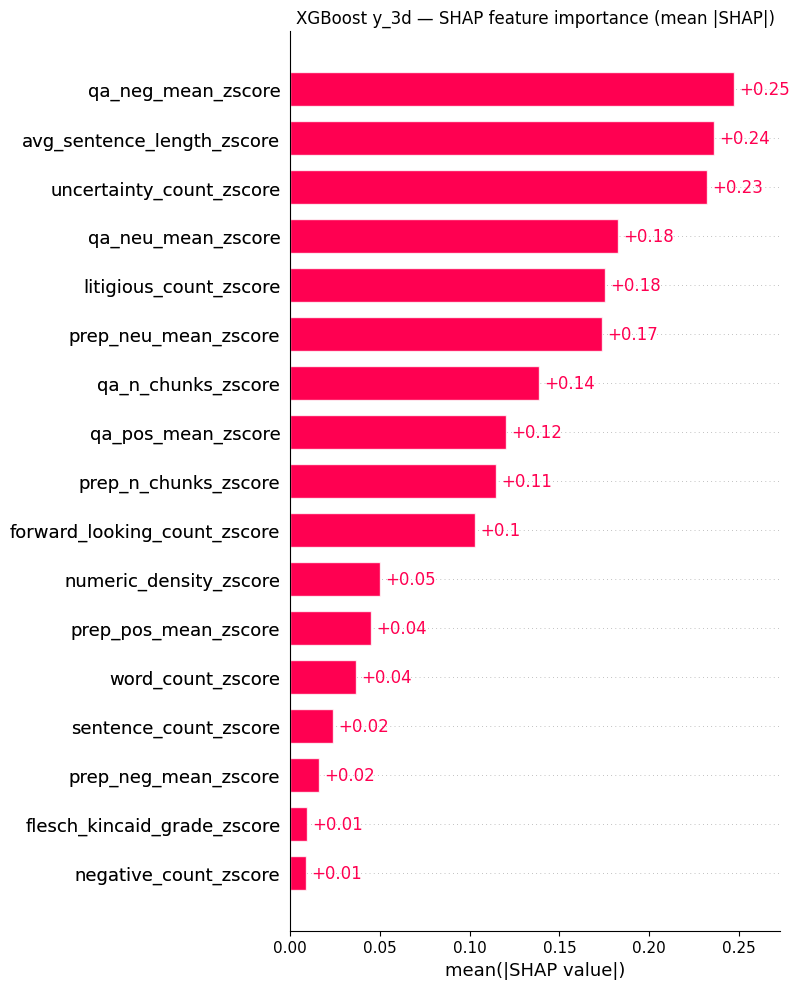

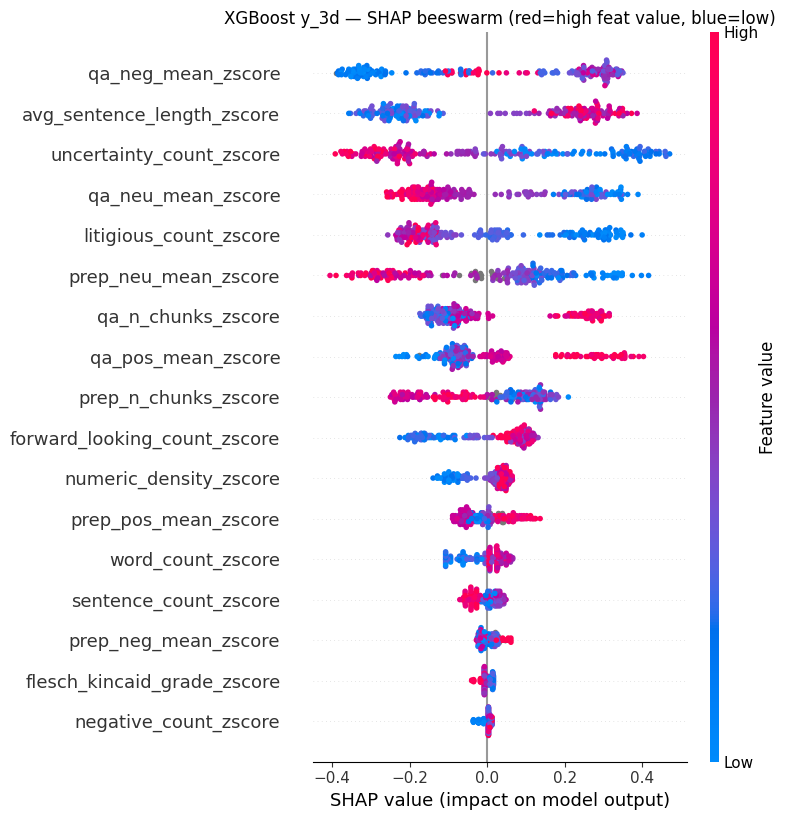

In [12]:
# Cell 11b — SHAP analysis: XGBoost y_3d shipping model
import shap
import matplotlib.pyplot as plt
import numpy as np

# Build explainer on the trained XGBoost model
xgb_y3d_model = xgb_combined_results["y_3d"]["model"]
explainer_xgb_y3d = shap.TreeExplainer(xgb_y3d_model)

# Compute SHAP values on training data (sorted by date — already true for X_train_full)
shap_xgb_y3d = explainer_xgb_y3d(X_train_full)

# Attach feature names (sometimes lost in pipeline)
shap_xgb_y3d.feature_names = FEATURES_COMBINED

print(f"SHAP values computed: {shap_xgb_y3d.values.shape}")
print(f"Expected (218 rows × 17 features): (218, 17)")

# Mean |SHAP| ranking — which features matter most overall
mean_abs_shap = np.abs(shap_xgb_y3d.values).mean(axis=0)
shap_ranking_xgb_y3d = sorted(
    zip(FEATURES_COMBINED, mean_abs_shap),
    key=lambda x: x[1],
    reverse=True
)

print("\n" + "="*60)
print("XGBoost y_3d — Feature importance (mean |SHAP|)")
print("="*60)
print(f"{'Rank':<5} {'Feature':<32} {'mean|SHAP|':>12} {'Source':>10}")
print("-" * 60)
for rank, (feat, importance) in enumerate(shap_ranking_xgb_y3d, 1):
    source = "FinBERT" if feat in FEATURES_FINBERT else "Lexicon"
    print(f"{rank:<5} {feat:<32} {importance:>12.4f} {source:>10}")

# Aggregate by feature family
lex_total = sum(imp for f, imp in shap_ranking_xgb_y3d if f in FEATURES_LEXICON)
fin_total = sum(imp for f, imp in shap_ranking_xgb_y3d if f in FEATURES_FINBERT)
total = lex_total + fin_total
print(f"\nFeature family contribution:")
print(f"  Lexicon (9 features):  {lex_total:.4f}  ({lex_total/total*100:.1f}%)")
print(f"  FinBERT (8 features):  {fin_total:.4f}  ({fin_total/total*100:.1f}%)")

# Bar plot
plt.figure(figsize=(10, 7))
shap.plots.bar(shap_xgb_y3d, max_display=17, show=False)
plt.title("XGBoost y_3d — SHAP feature importance (mean |SHAP|)")
plt.tight_layout()
plt.show()

# Beeswarm plot — shows direction and magnitude
plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_xgb_y3d, max_display=17, show=False)
plt.title("XGBoost y_3d — SHAP beeswarm (red=high feat value, blue=low)")
plt.tight_layout()
plt.show()

SHAP values computed: (200, 17)
Expected (200 rows × 17 features): (200, 17)

LR y_5d — Feature importance (mean |SHAP|)
Rank  Feature                            mean|SHAP|     Source
------------------------------------------------------------
1     litigious_count_zscore                 0.1577    Lexicon
2     avg_sentence_length_zscore             0.1574    Lexicon
3     qa_pos_mean_zscore                     0.1499    FinBERT
4     qa_neu_mean_zscore                     0.1461    FinBERT
5     qa_n_chunks_zscore                     0.1407    FinBERT
6     prep_neu_mean_zscore                   0.1345    FinBERT
7     uncertainty_count_zscore               0.1038    Lexicon
8     word_count_zscore                      0.1021    Lexicon
9     negative_count_zscore                  0.0818    Lexicon
10    qa_neg_mean_zscore                     0.0680    FinBERT
11    prep_neg_mean_zscore                   0.0545    FinBERT
12    prep_pos_mean_zscore                   0.0453    FinBERT

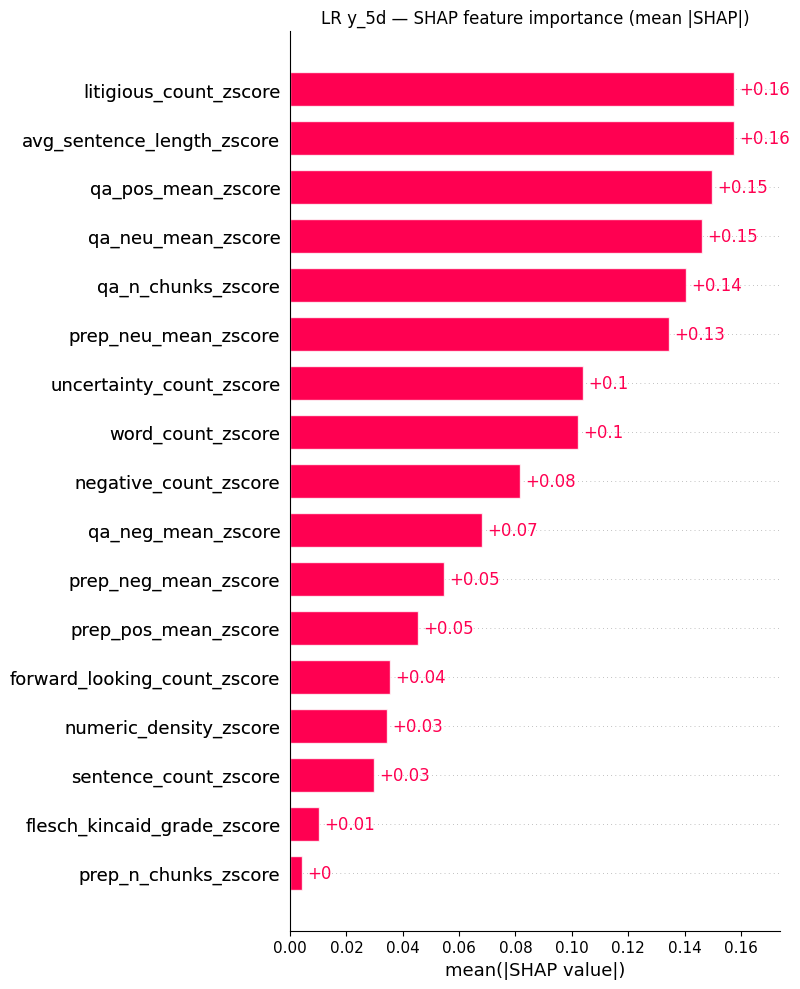

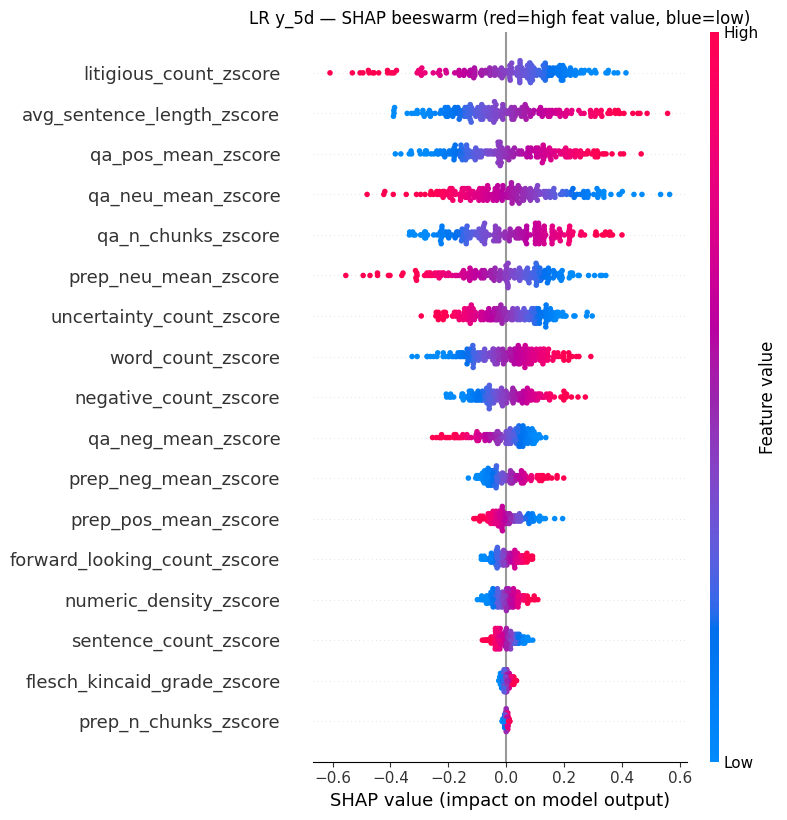

In [13]:
# Cell 12 — SHAP analysis: LR y_5d shipping model
import shap
import matplotlib.pyplot as plt
import numpy as np

# Extract scaler + LR from the pipeline
lr_y5d_pipeline = lr_combined_results["y_5d"]["model"]
scaler = lr_y5d_pipeline.named_steps["scaler"]
lr_model = lr_y5d_pipeline.named_steps["logreg"]

# Scale the clean training data (LR was trained on X_train_clean, 200 rows)
X_train_clean_scaled = scaler.transform(X_train_clean)

# LinearExplainer needs a background distribution
masker = shap.maskers.Independent(X_train_clean_scaled, max_samples=100)
explainer_lr_y5d = shap.LinearExplainer(lr_model, masker=masker)
shap_lr_y5d = explainer_lr_y5d(X_train_clean_scaled)

# Attach feature names
shap_lr_y5d.feature_names = FEATURES_COMBINED

print(f"SHAP values computed: {shap_lr_y5d.values.shape}")
print(f"Expected (200 rows × 17 features): (200, 17)")

# Mean |SHAP| ranking
mean_abs_shap = np.abs(shap_lr_y5d.values).mean(axis=0)
shap_ranking_lr_y5d = sorted(
    zip(FEATURES_COMBINED, mean_abs_shap),
    key=lambda x: x[1],
    reverse=True
)

print("\n" + "="*60)
print("LR y_5d — Feature importance (mean |SHAP|)")
print("="*60)
print(f"{'Rank':<5} {'Feature':<32} {'mean|SHAP|':>12} {'Source':>10}")
print("-" * 60)
for rank, (feat, importance) in enumerate(shap_ranking_lr_y5d, 1):
    source = "FinBERT" if feat in FEATURES_FINBERT else "Lexicon"
    print(f"{rank:<5} {feat:<32} {importance:>12.4f} {source:>10}")

# Aggregate by feature family
lex_total = sum(imp for f, imp in shap_ranking_lr_y5d if f in FEATURES_LEXICON)
fin_total = sum(imp for f, imp in shap_ranking_lr_y5d if f in FEATURES_FINBERT)
total = lex_total + fin_total
print(f"\nFeature family contribution:")
print(f"  Lexicon (9 features):  {lex_total:.4f}  ({lex_total/total*100:.1f}%)")
print(f"  FinBERT (8 features):  {fin_total:.4f}  ({fin_total/total*100:.1f}%)")

# LR coefficients (bonus — direct read of model parameters)
print("\n" + "="*60)
print("LR y_5d — Raw coefficients (sorted by |value|)")
print("="*60)
coef_pairs = sorted(
    zip(FEATURES_COMBINED, lr_model.coef_[0]),
    key=lambda x: abs(x[1]),
    reverse=True
)
print(f"{'Rank':<5} {'Feature':<32} {'Coefficient':>12} {'Direction':>11}")
print("-" * 60)
for rank, (feat, coef) in enumerate(coef_pairs, 1):
    direction = "→ risky" if coef > 0 else "→ safer"
    print(f"{rank:<5} {feat:<32} {coef:>+12.4f} {direction:>11}")

# Plots
plt.figure(figsize=(10, 7))
shap.plots.bar(shap_lr_y5d, max_display=17, show=False)
plt.title("LR y_5d — SHAP feature importance (mean |SHAP|)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_lr_y5d, max_display=17, show=False)
plt.title("LR y_5d — SHAP beeswarm (red=high feat value, blue=low)")
plt.tight_layout()
plt.show()

In [14]:
# Cell 13 — LR y_3d coefficients (NON-shipping model, for swap comparison)

lr_y3d_pipeline = lr_combined_results["y_3d"]["model"]
lr_y3d_model = lr_y3d_pipeline.named_steps["logreg"]

# Coefficients sorted by absolute magnitude
coef_pairs_y3d = sorted(
    zip(FEATURES_COMBINED, lr_y3d_model.coef_[0]),
    key=lambda x: abs(x[1]),
    reverse=True
)

print("=" * 60)
print("LR y_3d — Raw coefficients (sorted by |value|)")
print("=" * 60)
print(f"{'Rank':<5} {'Feature':<32} {'Coefficient':>12} {'Direction':>11}")
print("-" * 60)
for rank, (feat, coef) in enumerate(coef_pairs_y3d, 1):
    direction = "→ risky" if coef > 0 else "→ safer"
    print(f"{rank:<5} {feat:<32} {coef:>+12.4f} {direction:>11}")

# Cross-comparison: y_3d XGBoost SHAP rank vs y_3d LR coefficient rank
print("\n" + "=" * 75)
print("Swap-question diagnostic: y_3d feature ranks across XGBoost vs LR")
print("=" * 75)

# Build XGB SHAP rank lookup (already computed in Cell 11b)
xgb_rank = {feat: rank+1 for rank, (feat, _) in enumerate(shap_ranking_xgb_y3d)}
# Build LR coef rank lookup
lr_rank = {feat: rank+1 for rank, (feat, _) in enumerate(coef_pairs_y3d)}

print(f"{'Feature':<32} {'XGB rank':>9} {'LR rank':>9} {'Δ rank':>8} {'Source':>10}")
print("-" * 75)
# Sort by XGB rank for readability
for feat, _ in shap_ranking_xgb_y3d:
    source = "FinBERT" if feat in FEATURES_FINBERT else "Lexicon"
    delta = lr_rank[feat] - xgb_rank[feat]
    print(f"{feat:<32} {xgb_rank[feat]:>9d} {lr_rank[feat]:>9d} {delta:>+8d} {source:>10}")

# Spearman rank correlation: do the two models agree on which features matter?
from scipy.stats import spearmanr
xgb_ranks_arr = [xgb_rank[f] for f in FEATURES_COMBINED]
lr_ranks_arr = [lr_rank[f] for f in FEATURES_COMBINED]
rho, pval = spearmanr(xgb_ranks_arr, lr_ranks_arr)
print(f"\nSpearman rank correlation between XGB and LR feature importance: {rho:+.3f} (p={pval:.3f})")
print(f"  ρ near +1: models agree on feature importance ordering")
print(f"  ρ near  0: models use different features")
print(f"  ρ near -1: models use opposite features (extremely rare)")

LR y_3d — Raw coefficients (sorted by |value|)
Rank  Feature                           Coefficient   Direction
------------------------------------------------------------
1     litigious_count_zscore                -0.2184     → safer
2     qa_neu_mean_zscore                    -0.2009     → safer
3     avg_sentence_length_zscore            +0.1925     → risky
4     prep_neu_mean_zscore                  -0.1920     → safer
5     uncertainty_count_zscore              -0.1771     → safer
6     qa_pos_mean_zscore                    +0.1252     → risky
7     prep_n_chunks_zscore                  -0.1246     → safer
8     word_count_zscore                     +0.1120     → risky
9     qa_n_chunks_zscore                    +0.1021     → risky
10    negative_count_zscore                 +0.0999     → risky
11    numeric_density_zscore                +0.0790     → risky
12    sentence_count_zscore                 -0.0721     → safer
13    forward_looking_count_zscore          +0.0419     → ri

In [15]:
# Cell 14 — Day 5 results summary CSV (matches Day 3 format)

results_rows = []

# y_1d row — included for completeness, even though we didn't retrain (Day 3 proved it unstable)
results_rows.append({
    "window": "y_1d",
    "day": "Day 5",
    "model": "(skipped — Day 3 proved regime-dominated, test AUC 0.375)",
    "features": "N/A",
    "n_features": 0,
    "cv_val_auc": np.nan,
    "holdout_val_auc": np.nan,
    "test_auc": np.nan,
    "test_n": np.nan,
    "day3_test_auc": 0.375,
    "delta_vs_day3": np.nan,
})

# y_3d — shipping XGBoost combined
y3d = test_results_day5["y_3d"]
y3d_full = xgb_combined_results["y_3d"]
results_rows.append({
    "window": "y_3d",
    "day": "Day 5",
    "model": "XGBoost (tuned)",
    "features": "lexicon-z (9) + FinBERT-z (8)",
    "n_features": 17,
    "cv_val_auc": round(y3d_full["mean_cv_val_auc"], 4),
    "holdout_val_auc": round(y3d_full["val_auc_holdout"], 4),
    "test_auc": round(y3d["test_auc"], 4),
    "test_n": y3d["test_n"],
    "day3_test_auc": 0.525,
    "delta_vs_day3": round(y3d["test_auc"] - 0.525, 4),
})

# y_5d — shipping LR combined
y5d = test_results_day5["y_5d"]
y5d_full = lr_combined_results["y_5d"]
results_rows.append({
    "window": "y_5d",
    "day": "Day 5",
    "model": "Logistic Regression (L2, C=0.05)",
    "features": "lexicon-z (9) + FinBERT-z (8)",
    "n_features": 17,
    "cv_val_auc": round(y5d_full["mean_cv_val_auc"], 4),
    "holdout_val_auc": round(y5d_full["val_auc_holdout"], 4),
    "test_auc": round(y5d["test_auc"], 4),
    "test_n": y5d["test_n"],
    "day3_test_auc": 0.538,
    "delta_vs_day3": round(y5d["test_auc"] - 0.538, 4),
})

# Footnote row — XGBoost y_3d on clean test (40 rows)
results_rows.append({
    "window": "y_3d (clean test footnote)",
    "day": "Day 5",
    "model": "XGBoost on 40-row test (interview-format excluded)",
    "features": "lexicon-z (9) + FinBERT-z (8)",
    "n_features": 17,
    "cv_val_auc": np.nan,
    "holdout_val_auc": np.nan,
    "test_auc": round(xgb_y3d_on_clean_auc, 4),
    "test_n": 40,
    "day3_test_auc": 0.525,
    "delta_vs_day3": round(xgb_y3d_on_clean_auc - 0.525, 4),
})

day5_results_df = pd.DataFrame(results_rows)

# Save
OUTPUT_PATH = REPO_ROOT / "data" / "processed" / "day5_results_summary.csv"
day5_results_df.to_csv(OUTPUT_PATH, index=False)

print(f"Saved to: {OUTPUT_PATH}\n")
print(day5_results_df.to_string(index=False))

Saved to: d:\Projects\risk-radar\data\processed\day5_results_summary.csv

                    window   day                                                     model                      features  n_features  cv_val_auc  holdout_val_auc  test_auc  test_n  day3_test_auc  delta_vs_day3
                      y_1d Day 5 (skipped — Day 3 proved regime-dominated, test AUC 0.375)                           N/A           0         NaN              NaN       NaN     NaN          0.375            NaN
                      y_3d Day 5                                           XGBoost (tuned) lexicon-z (9) + FinBERT-z (8)          17      0.5961              0.7    0.5500    44.0          0.525         0.0250
                      y_5d Day 5                          Logistic Regression (L2, C=0.05) lexicon-z (9) + FinBERT-z (8)          17      0.5777              0.5    0.5657    40.0          0.538         0.0277
y_3d (clean test footnote) Day 5        XGBoost on 40-row test (interview-format exclu

In [16]:
# Cell 15 — Save Day 5 shipping models
import joblib

MODELS_DIR = REPO_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

# Save shipping models (note _v2 suffix to not overwrite Day 3's models)
shipping_y3d_model = xgb_combined_results["y_3d"]["model"]
shipping_y5d_model = lr_combined_results["y_5d"]["model"]

joblib.dump(shipping_y3d_model, MODELS_DIR / "model_y3d_xgb_v2.joblib")
joblib.dump(shipping_y5d_model, MODELS_DIR / "model_y5d_lr_v2.joblib")
joblib.dump(FEATURES_COMBINED, MODELS_DIR / "feature_cols_v2.joblib")

# Verify by loading back and predicting one row
test_load_y3d = joblib.load(MODELS_DIR / "model_y3d_xgb_v2.joblib")
test_load_y5d = joblib.load(MODELS_DIR / "model_y5d_lr_v2.joblib")
test_load_feats = joblib.load(MODELS_DIR / "feature_cols_v2.joblib")

# Sanity check 1: feature list matches
assert test_load_feats == FEATURES_COMBINED, "Feature list mismatch on reload"

# Sanity check 2: reload produces same predictions on test
reload_y3d_pred = test_load_y3d.predict_proba(X_test_combined_full)[:, 1]
original_y3d_pred = test_results_day5["y_3d"]["pred_proba"]
assert np.allclose(reload_y3d_pred, original_y3d_pred), "y_3d reload predictions differ"

reload_y5d_pred = test_load_y5d.predict_proba(X_test_combined_clean)[:, 1]
original_y5d_pred = test_results_day5["y_5d"]["pred_proba"]
assert np.allclose(reload_y5d_pred, original_y5d_pred), "y_5d reload predictions differ"

print("Saved files:")
for fname in ["model_y3d_xgb_v2.joblib", "model_y5d_lr_v2.joblib", "feature_cols_v2.joblib"]:
    fpath = MODELS_DIR / fname
    size_kb = fpath.stat().st_size / 1024
    print(f"  {fname:<35} {size_kb:>8.1f} KB")

print("\n✓ Models reload correctly")
print("✓ Reloaded models reproduce original test predictions exactly")

# Final inventory of models/ directory
print(f"\nAll files in {MODELS_DIR}:")
for f in sorted(MODELS_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    age = "Day 3" if "v2" not in f.name and f.name != "feature_cols.joblib" else ("Day 5" if "v2" in f.name else "Day 3")
    print(f"  {f.name:<35} {size_kb:>8.1f} KB   ({age})")

Saved files:
  model_y3d_xgb_v2.joblib                 92.3 KB
  model_y5d_lr_v2.joblib                   2.5 KB
  feature_cols_v2.joblib                   0.4 KB

✓ Models reload correctly
✓ Reloaded models reproduce original test predictions exactly

All files in d:\Projects\risk-radar\models:
  feature_cols.joblib                      0.4 KB   (Day 3)
  feature_cols_v2.joblib                   0.4 KB   (Day 5)
  model_y1d_lr_v1.joblib                   2.5 KB   (Day 3)
  model_y3d_lr_v2.joblib                   2.5 KB   (Day 5)
  model_y3d_xgb_v2.joblib                 92.3 KB   (Day 5)
  model_y5d_lr_v2.joblib                   2.5 KB   (Day 5)
  model_y5d_xgboost.joblib               101.3 KB   (Day 3)


In [17]:
# Cell 15b — Rename Day 5 files to avoid 'v2' collision with Day 3
import shutil

rename_map = {
    "model_y3d_xgb_v2.joblib": "model_y3d_xgb_day5.joblib",
    "model_y5d_lr_v2.joblib": "model_y5d_lr_day5.joblib",
    "feature_cols_v2.joblib": "feature_cols_day5.joblib",
}

for old_name, new_name in rename_map.items():
    old_path = MODELS_DIR / old_name
    new_path = MODELS_DIR / new_name
    
    if not old_path.exists():
        print(f"  SKIP: {old_name} does not exist")
        continue
    if new_path.exists():
        print(f"  SKIP: {new_name} already exists — manual review needed")
        continue
    
    shutil.move(str(old_path), str(new_path))
    print(f"  Renamed: {old_name}  →  {new_name}")

# Verify reload still works after rename
test_y3d = joblib.load(MODELS_DIR / "model_y3d_xgb_day5.joblib")
test_y5d = joblib.load(MODELS_DIR / "model_y5d_lr_day5.joblib")
test_feats = joblib.load(MODELS_DIR / "feature_cols_day5.joblib")

reload_y3d_pred = test_y3d.predict_proba(X_test_combined_full)[:, 1]
reload_y5d_pred = test_y5d.predict_proba(X_test_combined_clean)[:, 1]

assert np.allclose(reload_y3d_pred, test_results_day5["y_3d"]["pred_proba"])
assert np.allclose(reload_y5d_pred, test_results_day5["y_5d"]["pred_proba"])
assert test_feats == FEATURES_COMBINED

print("\n✓ Renamed files load correctly and reproduce test predictions")

# Final inventory — corrected this time
print(f"\nFinal {MODELS_DIR} contents:")
for f in sorted(MODELS_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    origin = "Day 5" if "_day5" in f.name else "Day 3"
    print(f"  {f.name:<40} {size_kb:>8.1f} KB   ({origin})")

  Renamed: model_y3d_xgb_v2.joblib  →  model_y3d_xgb_day5.joblib
  Renamed: model_y5d_lr_v2.joblib  →  model_y5d_lr_day5.joblib
  Renamed: feature_cols_v2.joblib  →  feature_cols_day5.joblib

✓ Renamed files load correctly and reproduce test predictions

Final d:\Projects\risk-radar\models contents:
  feature_cols.joblib                           0.4 KB   (Day 3)
  feature_cols_day5.joblib                      0.4 KB   (Day 5)
  model_y1d_lr_v1.joblib                        2.5 KB   (Day 3)
  model_y3d_lr_v2.joblib                        2.5 KB   (Day 3)
  model_y3d_xgb_day5.joblib                    92.3 KB   (Day 5)
  model_y5d_lr_day5.joblib                      2.5 KB   (Day 5)
  model_y5d_xgboost.joblib                    101.3 KB   (Day 3)
